In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Load data
df = pd.read_csv("/content/drive/MyDrive/Copy of formatting_data - formatting_data.csv")

# ========================================================================
# 1. TARGET & FEATURE CLEANING
# ========================================================================
# Convert Churn_Risk to binary
df['Churn_Risk'] = df['Churn_Risk'].map({'Low': 0, 'High': 1})

# Drop non-predictive columns
non_predictive = [
    'Name', 'Email', 'Customer ID', 'Transaction Date', 'IP Address',
    'POS_Transaction_ID', 'Zip Code', 'Product Name', 'Language',
    'Store_Location_City', 'Store_Location_Country', 'Delivery_Location_City',
    'Delivery_Location_Country', 'Referral Source'
]
df = df.drop(columns=non_predictive, errors='ignore')

# ========================================================================
# 2. DATA SPLITTING
# ========================================================================
X = df.drop('Churn_Risk', axis=1)
y = df['Churn_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ========================================================================
# 3. AUTOMATIC FEATURE PROCESSING
# ========================================================================
# Identify feature types
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

# ========================================================================
# 4. FEATURE SELECTION WITH MUTUAL INFORMATION
# ========================================================================
# Process training data
X_train_processed = preprocessor.fit_transform(X_train)

# Get total processed features
total_processed_features = X_train_processed.shape[1]

# Correctly mark discrete features (first N categorical, others continuous)
discrete_features = [True] * len(categorical_cols) + [False] * (total_processed_features - len(categorical_cols))

# Compute MI scores
mi_scores = mutual_info_classif(X_train_processed, y_train, discrete_features=discrete_features)

# Get feature names
feature_names = (
    preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist() +
    numerical_cols +
    [f"rem_{i}" for i in range(total_processed_features - len(categorical_cols) - len(numerical_cols))]
)

# Select top 10 features
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
top_features = mi_df.nlargest(10, 'MI_Score')['Feature'].tolist()
print("Top Predictive Features:\n", top_features)

# ========================================================================
# 5. MODEL TRAINING
# ========================================================================
# Keep only selected features
X_train_selected = pd.DataFrame(X_train_processed, columns=feature_names)[top_features]
X_test_selected = pd.DataFrame(preprocessor.transform(X_test), columns=feature_names)[top_features]

# Train model
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_selected, y_train)

# Evaluate
y_pred = model.predict(X_test_selected)
y_proba = model.predict_proba(X_test_selected)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.2f}")

Top Predictive Features:
 ['Order_Fulfillment_Time', 'Order_ID', 'First Interaction Date', 'Bounce Rate', 'Chargebacks', 'Clickstream Data', 'Location', 'Ticket Resolution Time', 'Average Response Time', 'Average Resolution Time']

Classification Report:
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       539
     Churned       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

AUC-ROC: 1.00


In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_train_selected, y_train, cv=5)
print("Cross-Validation Scores:", scores)

Cross-Validation Scores: [1. 1. 1. 1. 1.]


In [ ]:
print("Top Features:\n", top_features)

Top Features:
 ['cat__Order_Fulfillment_Time', 'cat__Order_ID', 'cat__First Interaction Date', 'cat__Clickstream Data', 'num__Ad_Clicks', 'num__Return_Refund_Rate', 'cat__Location', 'num__Product Rating', 'num__Product_Views', 'num__Purchase_Frequency']


In [ ]:
mi_df

,Feature,MI_Score
0,cat__Location,0.514536
1,cat__Gender,0.094033
2,cat__Language,0.117524
3,cat__Purchase History,0.325377
4,cat__Payment Method,0.392484
...,...,...
117,num__Return_Rate,0.382628
118,num__Defective_Flag,0.245850
119,remainder__Newsletter Opened,0.077137
120,remainder__Social Media Share,0.050253


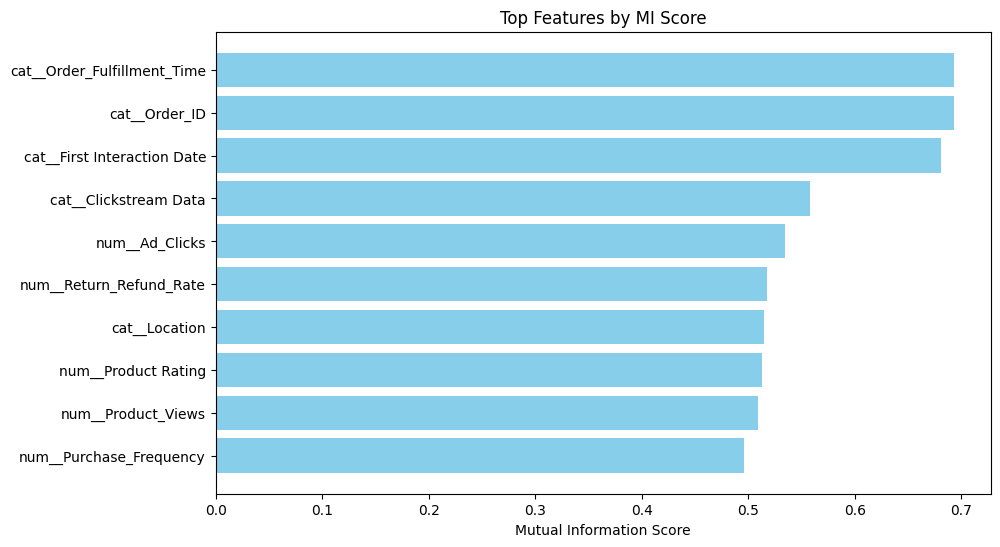

In [ ]:
import matplotlib.pyplot as plt

# Filter MI scores for top features
top_mi_scores = mi_df[mi_df['Feature'].isin(top_features)].sort_values('MI_Score', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_mi_scores['Feature'], top_mi_scores['MI_Score'], color='skyblue')
plt.xlabel('Mutual Information Score')
plt.title('Top Features by MI Score')
plt.gca().invert_yaxis()  # Highest MI at the top
plt.show()

Original Class Distribution:
Churn_Risk
Low     2695
High     305
Name: count, dtype: int64

Mapped Class Distribution:
Churn_Risk
0    2695
1     305
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/cluster/_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.1


Top 10 Features by MI Score:
                         Feature  MI_Score
48   cat__Order_Fulfillment_Time  0.693147
44                 cat__Order_ID  0.693147
16   cat__First Interaction Date  0.681029
6          cat__Clickstream Data  0.557694
113               num__Ad_Clicks  0.532656
112      num__Return_Refund_Rate  0.515804
0                  cat__Location  0.514536
57           num__Product Rating  0.508618
110           num__Product_Views  0.508522
109      num__Purchase_Frequency  0.496984


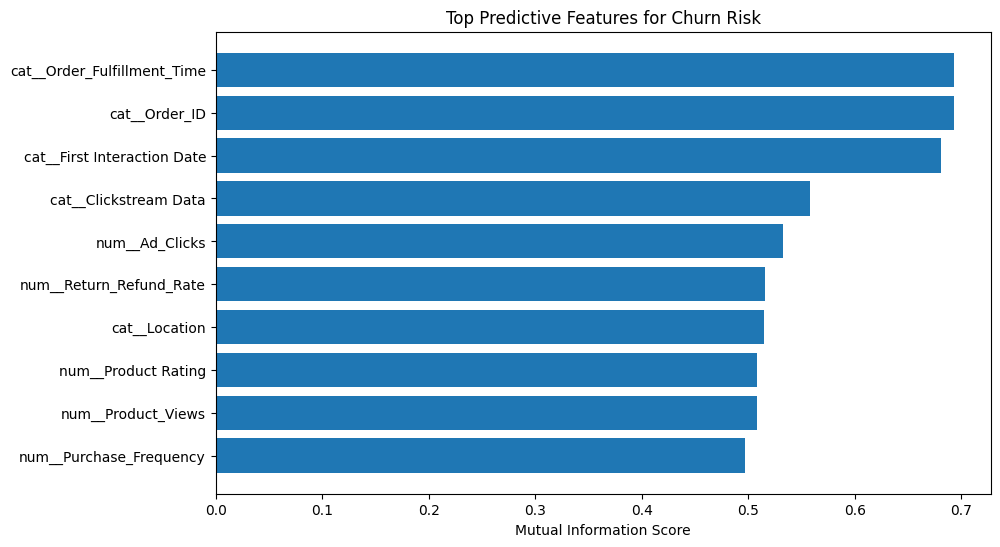

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


ValueError: X has 10 features, but RandomForestClassifier is expecting 122 features as input.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# Load data
df = pd.read_csv("/content/drive/MyDrive/Copy of formatting_data - formatting_data.csv")

# ========================================================================
# 1. TARGET VALIDATION & CLASS BALANCE FIX
# ========================================================================
# Verify original class distribution
print("Original Class Distribution:")
print(df['Churn_Risk'].value_counts())

# Map to binary (ensure no data loss)
df['Churn_Risk'] = df['Churn_Risk'].map({'Low': 0, 'High': 1})
print("\nMapped Class Distribution:")
print(df['Churn_Risk'].value_counts())

# ========================================================================
# 2. FEATURE CLEANING (Remove leakage candidates)
# ========================================================================
leakage_candidates = [
    'Subscription Cancelled', 'Churn Reason', 'Return_Flag',
    'Churned', 'Last Purchase Date', 'Customer ID'
]
non_predictive = [
    'Name', 'Email', 'Transaction Date', 'IP Address',
    'POS_Transaction_ID', 'Zip Code', 'Product Name'
]
df = df.drop(columns=leakage_candidates + non_predictive, errors='ignore')

# ========================================================================
# 3. DATA SPLITTING WITH STRATIFICATION
# ========================================================================
X = df.drop('Churn_Risk', axis=1)
y = df['Churn_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ========================================================================
# 4. PROCESSING & FEATURE SELECTION
# ========================================================================
# Identify features
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

# Process data
X_train_processed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

# After preprocessing and SMOTE
X_train_processed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

# Mark categorical features dynamically
discrete_mask = [name.startswith('cat__') for name in feature_names]

# Compute MI scores
mi_scores = mutual_info_classif(X_train_res, y_train_res, discrete_features=discrete_mask)

# Validate lengths
assert len(feature_names) == len(mi_scores), "Mismatch in feature names and MI scores!"

# Create MI DataFrame
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})

# Select top 10 features
top_features = mi_df.nlargest(10, 'MI_Score')['Feature'].tolist()
print("\nTop 10 Features by MI Score:")
print(mi_df.nlargest(10, 'MI_Score'))

# ========================================================================
# 5. VISUALIZE MI SCORES
# ========================================================================
plt.figure(figsize=(10, 6))
plt.barh(top_features, mi_df.nlargest(10, 'MI_Score')['MI_Score'], color='#1f77b4')
plt.xlabel('Mutual Information Score')
plt.title('Top Predictive Features for Churn Risk')
plt.gca().invert_yaxis()
plt.show()

# ========================================================================
# 6. MODEL TRAINING & EVALUATION
# ========================================================================
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_res, y_train_res)

# Process test data
X_test_processed = preprocessor.transform(X_test)
X_test_selected = pd.DataFrame(X_test_processed, columns=feature_names)[top_features]

# Predict
y_pred = model.predict(X_test_selected)
y_proba = model.predict_proba(X_test_selected)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.2f}")

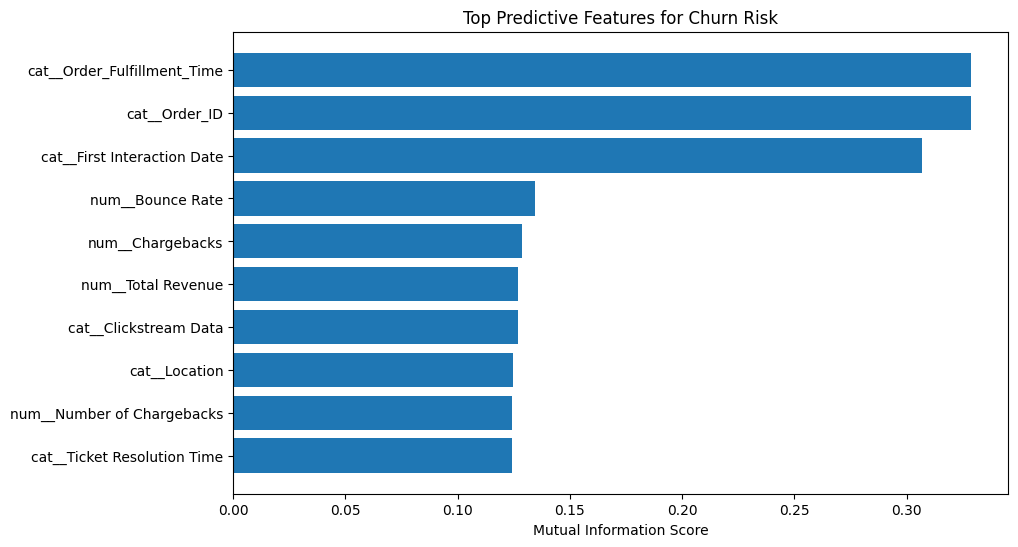


Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       539
   High Risk       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

AUC-ROC: 1.00


In [ ]:
# ========================================================================
# 1. DATA PREPROCESSING
# ========================================================================
# Preprocess data FIRST
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get valid feature names
feature_names = preprocessor.get_feature_names_out()

# ========================================================================
# 2. FEATURE SELECTION (BEFORE SMOTE)
# ========================================================================
# Compute MI scores on original training data (before resampling)
discrete_mask = [name.startswith('cat__') for name in feature_names]
mi_scores = mutual_info_classif(X_train_processed, y_train, discrete_features=discrete_mask)

# Create MI DataFrame and select top 10 features
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
top_features = mi_df.nlargest(10, 'MI_Score')['Feature'].tolist()

# ========================================================================
#  VISUALIZE MI SCORES
# ========================================================================
plt.figure(figsize=(10, 6))
plt.barh(top_features, mi_df.nlargest(10, 'MI_Score')['MI_Score'], color='#1f77b4')
plt.xlabel('Mutual Information Score')
plt.title('Top Predictive Features for Churn Risk')
plt.gca().invert_yaxis()
plt.show()
# ========================================================================
# 3. BALANCE CLASSES WITH SMOTE (ON SELECTED FEATURES)
# ========================================================================
# Select top features from processed data
X_train_selected = pd.DataFrame(X_train_processed, columns=feature_names)[top_features]
X_test_selected = pd.DataFrame(X_test_processed, columns=feature_names)[top_features]

# Apply SMOTE to selected features
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_selected, y_train)

# ========================================================================
# 4. MODEL TRAINING & EVALUATION
# ========================================================================
model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train_res, y_train_res)

# Predict using the SAME selected features
y_pred = model.predict(X_test_selected)
y_proba = model.predict_proba(X_test_selected)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.2f}")

Top 10 Features by MI Score:
                           Feature  MI_Score
48    cat__Order_Fulfillment_Time  0.328730
56               num__Bounce Rate  0.135166
97     num__Number of Chargebacks  0.128016
6           cat__Clickstream Data  0.126846
0                   cat__Location  0.124791
21    cat__Ticket Resolution Time  0.124020
20     cat__Average Response Time  0.124020
19   cat__Average Resolution Time  0.124020
30                    cat__source  0.124020
120              num__Return_Rate  0.121495


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:54:22] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


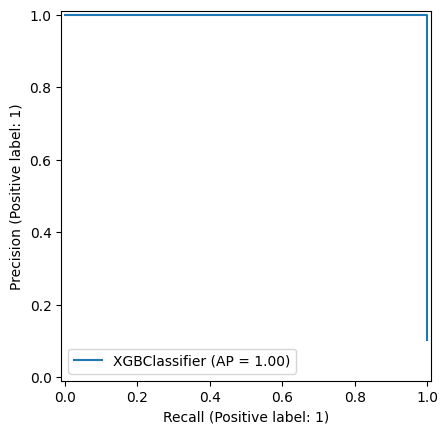


Classification Report:
              precision    recall  f1-score   support

    Low Risk       1.00      1.00      1.00       539
   High Risk       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600

AUC-ROC: 1.00


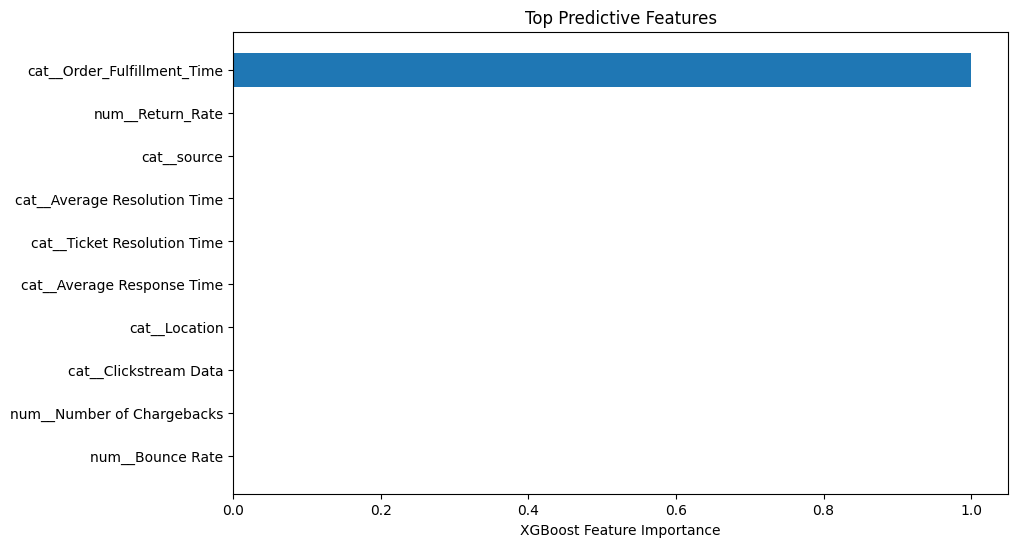

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# ========================================================================
# 1. DATA LOADING & TARGET MAPPING
# ========================================================================
df = pd.read_csv("/content/drive/MyDrive/Copy of formatting_data - formatting_data.csv")
df['Churn_Risk'] = df['Churn_Risk'].map({'Low': 0, 'High': 1})

# ========================================================================
# 2. FEATURE CLEANING
# ========================================================================
non_predictive = ['Name', 'Email', 'Customer ID', 'Transaction Date',
                 'IP Address', 'POS_Transaction_ID', 'Zip Code',
                 'Order_ID', 'First Interaction Date', 'Product Name']
df = df.drop(columns=non_predictive, errors='ignore')

# ========================================================================
# 3. DATA SPLITTING
# ========================================================================
X = df.drop('Churn_Risk', axis=1)
y = df['Churn_Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ========================================================================
# 4. PREPROCESSING PIPELINE
# ========================================================================
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

# ========================================================================
# 5. FEATURE SELECTION WORKFLOW
# ========================================================================
# Process training data
X_train_processed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

# Compute MI scores
discrete_mask = [name.startswith('cat__') for name in feature_names]
mi_scores = mutual_info_classif(X_train_processed, y_train, discrete_features=discrete_mask)

# Select top 10 features
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
top_features = mi_df.nlargest(10, 'MI_Score')['Feature'].tolist()
print("Top 10 Features by MI Score:\n", mi_df.nlargest(10, 'MI_Score'))

# ========================================================================
# 6. DATA BALANCING & MODEL TRAINING
# ========================================================================
# Select features before SMOTE
X_train_selected = pd.DataFrame(X_train_processed, columns=feature_names)[top_features]
X_test_selected = pd.DataFrame(preprocessor.transform(X_test), columns=feature_names)[top_features]

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_selected, y_train)

# Calculate class weight ratio
scale_pos_weight = len(y_train_res[y_train_res == 0]) / len(y_train_res[y_train_res == 1])

# Initialize XGBoost
model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    use_label_encoder=False,
    tree_method='hist'
)

# Train model
model.fit(X_train_res, y_train_res)

# ========================================================================
# 7. EVALUATION & VISUALIZATION
# ========================================================================
y_pred = model.predict(X_test_selected)
y_proba = model.predict_proba(X_test_selected)[:, 1]



PrecisionRecallDisplay.from_estimator(model, X_test_selected, y_test)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Low Risk", "High Risk"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.2f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
sorted_idx = model.feature_importances_.argsort()
plt.barh(np.array(top_features)[sorted_idx], model.feature_importances_[sorted_idx])
plt.xlabel("XGBoost Feature Importance")
plt.title("Top Predictive Features")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_fscore_support

def train_evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(classification_report(y_test, y_pred))
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    return precision, recall, f1

# Initialize models
xgb_model = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
    eval_metric='logloss',
    use_label_encoder=False
)

rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_jobs=-1
)

# Train and evaluate
print("XGBoost Results:")
xgb_metrics = train_evaluate_model(xgb_model, X_train_res, y_train_res, X_test_selected, y_test)
print("\nRandom Forest Results:")
rf_metrics = train_evaluate_model(rf_model, X_train_res, y_train_res, X_test_selected, y_test)

XGBoost Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       539
           1       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


Random Forest Results:


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:54:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       539
           1       1.00      1.00      1.00        61

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [ ]:
# ========================================================================
# 1. IMPORTS & CONFIGURATION
# ========================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# ========================================================================
# 2. DATA PROCESSING & FEATURE SELECTION
# ========================================================================
# Load and clean data
df = pd.read_csv("/content/drive/MyDrive/Copy of formatting_data - formatting_data.csv")
df['Churn_Risk'] = df['Churn_Risk'].map({'Low': 0, 'High': 1})




# Clean non-predictive columns
non_predictive = ['Name', 'Email', 'Customer ID', 'Transaction Date',
                 'IP Address', 'POS_Transaction_ID', 'Zip Code']
df = df.drop(columns=non_predictive, errors='ignore')

# ========================================================================
# DATA SPLITTING
# ========================================================================
X = df.drop('Churn_Risk', axis=1)
y = df['Churn_Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# After original train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Separate test classes
minority_mask = y_test == 1
X_test_min = X_test[minority_mask]
y_test_min = y_test[minority_mask]
X_test_maj = X_test[~minority_mask]
y_test_maj = y_test[~minority_mask]

# Downsample majority
X_test_maj_down, y_test_maj_down = resample(
    X_test_maj,
    y_test_maj,
    n_samples=len(X_test_min),  # Match minority count
    random_state=42
)

# Combine and shuffle
X_test_balanced = pd.concat([X_test_min, X_test_maj_down])
y_test_balanced = pd.concat([y_test_min, y_test_maj_down])
shuffled_idx = np.random.permutation(len(X_test_balanced))
X_test_balanced = X_test_balanced.iloc[shuffled_idx]
y_test_balanced = y_test_balanced.iloc[shuffled_idx]



# Preprocessing
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

# Feature selection
X_train_processed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()
discrete_mask = [name.startswith('cat__') for name in feature_names]

# Select top 10 features
mi_scores = mutual_info_classif(X_train_processed, y_train, discrete_features=discrete_mask)
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
top_features = mi_df.nlargest(10, 'MI_Score')['Feature'].tolist()

# Apply selection
X_train_selected = pd.DataFrame(X_train_processed, columns=feature_names)[top_features]
X_test_balanced_selected = pd.DataFrame(preprocessor.transform(X_test_balanced), columns=feature_names)[top_features]

# Balance training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_selected, y_train)

# ========================================================================
# 3. IMPROVED NEURAL NETWORK
# ========================================================================
def create_nn(input_shape):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',  # Single loss function
        metrics=['AUC', 'Precision', 'Recall']
    )
    return model

# Train with class weights (not loss_weights)
class_weights = {0: 1, 1: 10}  # Penalize class 1 (churn) 10x more

# Train model
nn_model = create_nn(X_train_res.shape[1])
early_stopping = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
history = nn_model.fit(
    X_train_res, y_train_res,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=0
)

# Evaluate
print("Neural Network Performance:")
y_pred_nn = (nn_model.predict(X_test_balanced_selected) > 0.5).astype(int)
print(classification_report(y_test_balanced, y_pred_nn))

# ========================================================================
# 4. ROBUST ENSEMBLE STACKING
# ========================================================================
# Base models
xgb = XGBClassifier(scale_pos_weight=5, eval_metric='logloss', use_label_encoder=False)
rf = RandomForestClassifier(class_weight='balanced', n_jobs=-1)

# Stacking with cross-validation
stack_model = StackingClassifier(
    estimators=[('xgb', xgb), ('rf', rf)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

# Train and evaluate
stack_model.fit(X_train_res, y_train_res)
print("\nStacking Model Performance:")
y_pred_stack = stack_model.predict(X_test_balanced_selected)
print(classification_report(y_test_balanced, y_pred_stack))

# ========================================================================
# 5. FEATURE CONSISTENCY CHECK
# ========================================================================
# Verify feature alignment
train_features = set(X_train_res.columns)
test_features = set(X_test_balanced_selected.columns)
assert train_features == test_features, f"Feature mismatch! Missing: {train_features - test_features}, Extra: {test_features - train_features}"

Neural Network Performance:
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
              precision    recall  f1-score   support

           0       0.52      0.97      0.67        61
           1       0.75      0.10      0.17        61

    accuracy                           0.53       122
   macro avg       0.63      0.53      0.42       122
weighted avg       0.63      0.53      0.42       122


Stacking Model Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        61

    accuracy                           1.00       122
   macro avg       1.00      1.00      1.00       122
weighted avg       1.00      1.00      1.00       122



In [ ]:
# ========================================================================
# 1. IMPORTS & CONFIGURATION
# ========================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# ========================================================================
# 2. DATA PREPARATION & BALANCING
# ========================================================================
# Load data
df = pd.read_csv("/content/drive/MyDrive/Copy of formatting_data - formatting_data.csv")
df['Churn_Risk'] = df['Churn_Risk'].map({'Low': 0, 'High': 1})

# Clean data
non_predictive = ['Name', 'Email', 'Customer ID', 'Transaction Date',
                 'IP Address', 'POS_Transaction_ID', 'Zip Code']
df = df.drop(columns=non_predictive, errors='ignore')

# Split original data
X = df.drop('Churn_Risk', axis=1)
y = df['Churn_Risk']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Create balanced test set (optional)
X_test_minority = X_test[y_test == 1]
X_test_majority = X_test[y_test == 0].sample(n=len(X_test_minority), random_state=42)
X_test_balanced = pd.concat([X_test_minority, X_test_majority])
y_test_balanced = pd.concat([y_test[y_test == 1], y_test[y_test == 0].sample(n=len(X_test_minority))])

# ========================================================================
# 3. FEATURE ENGINEERING
# ========================================================================
# Preprocessing pipeline
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

# Fit on training data
X_train_processed = preprocessor.fit_transform(X_train)
feature_names = preprocessor.get_feature_names_out()

# Feature selection
discrete_mask = [name.startswith('cat__') for name in feature_names]
mi_scores = mutual_info_classif(X_train_processed, y_train, discrete_features=discrete_mask)
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
top_features = mi_df.nlargest(15, 'MI_Score')['Feature'].tolist()

# Apply selection
X_train_selected = pd.DataFrame(X_train_processed, columns=feature_names)[top_features]
X_test_selected = pd.DataFrame(preprocessor.transform(X_test), columns=feature_names)[top_features]
X_test_balanced_selected = pd.DataFrame(preprocessor.transform(X_test_balanced), columns=feature_names)[top_features]

# Balance training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_selected, y_train)

# ========================================================================
# 4. TENSORFLOW/KERAS DEEP LEARNING MODEL
# ========================================================================
# Neural network architecture
def create_nn(input_shape):
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_shape,)),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

# Train model
nn_model = create_nn(X_train_res.shape[1])
early_stopping = callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_res, y_train_res,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=0
)

# Evaluate
print("\nDeep Learning Performance:")
y_proba_nn = nn_model.predict(X_test_balanced_selected)
y_pred_nn = (y_proba_nn > 0.5).astype(int)
print(classification_report(y_test_balanced, y_pred_nn))

# ========================================================================
# 5. ENSEMBLE STACKING MODEL
# ========================================================================
# Define base models
base_models = [
    ('xgb', XGBClassifier(
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        eval_metric='logloss',
        use_label_encoder=False
    )),
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        n_jobs=-1
    ))
]

# Build stack
stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=RandomForestClassifier(),
    stack_method='predict_proba',
    n_jobs=-1
)

# Train and evaluate
stack_model.fit(X_train_res, y_train_res)
print("\nEnsemble Stacking Performance:")
y_pred_stack = stack_model.predict(X_test_balanced_selected)
print(classification_report(y_test_balanced, y_pred_stack))

# ========================================================================
# 6. ADVANCED ANALYSIS & VISUALIZATION
# ========================================================================
# Precision-Recall Curve
plt.figure(figsize=(10, 6))
for name, model in [('XGBoost', xgb_model), ('Random Forest', rf_model),
                   ('Neural Network', nn_model), ('Stacking', stack_model)]:
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_balanced_selected)[:, 1]
    else:  # For Keras model
        y_proba = model.predict(X_test_balanced_selected).flatten()
    precision, recall, _ = precision_recall_curve(y_test_balanced, y_proba)
    plt.plot(recall, precision, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.show()

# Feature Importance Comparison
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# XGBoost Importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=top_features).sort_values()
xgb_imp.plot(kind='barh', ax=ax[0], title='XGBoost Feature Importance')

# Neural Network Feature Importance (permutation)
from sklearn.inspection import permutation_importance
nn_imp = permutation_importance(nn_model, X_test_balanced_selected, y_test_balanced, n_repeats=5)
nn_imp_df = pd.Series(nn_imp.importances_mean, index=top_features).sort_values()
nn_imp_df.plot(kind='barh', ax=ax[1], title='Neural Network Feature Importance')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Deep Learning Performance:
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        61
           1       0.00      0.00      0.00        61

    accuracy                           0.50       122
   macro avg       0.25      0.50      0.33       122
weighted avg       0.25      0.50      0.33       122



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Ensemble Stacking Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        61
           1       1.00      1.00      1.00        61

    accuracy                           1.00       122
   macro avg       1.00      1.00      1.00       122
weighted avg       1.00      1.00      1.00       122



ValueError: feature_names mismatch: ['cat__Order_Fulfillment_Time', 'num__Bounce Rate', 'num__Number of Chargebacks', 'cat__Clickstream Data', 'cat__Location', 'cat__Ticket Resolution Time', 'cat__Average Response Time', 'cat__Average Resolution Time', 'cat__source', 'num__Return_Rate'] ['cat__Order_Fulfillment_Time', 'cat__Order_ID', 'cat__First Interaction Date', 'num__Bounce Rate', 'num__Total Revenue', 'cat__Clickstream Data', 'num__Awareness Stage', 'cat__Location', 'num__Chargebacks', 'cat__Ticket Resolution Time', 'cat__Average Response Time', 'cat__Average Resolution Time', 'cat__source', 'num__Number of Chargebacks', 'num__Product Price']
expected num__Return_Rate in input data
training data did not have the following fields: num__Total Revenue, num__Product Price, num__Awareness Stage, cat__Order_ID, cat__First Interaction Date, num__Chargebacks

<Figure size 1000x600 with 0 Axes>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')